# Pattern Distribution Scanner

Scan S&P 500 stocks for technical patterns on a specified date and visualize the distribution.

**Patterns Scanned:**
- Volume_Surge_Reversal: Volume surge (>2x) with RSI < 35
- Oversold_Reversal: RSI < 30 with 3+ consecutive red candles
- Deep_Pullback: Price >5% below MA20 with RSI < 40
- Overbought_Momentum: RSI > 70 with green candles
- Strong_Uptrend: Above all MAs (9/20/50) with 3+ green candles

## 1. Configuration - Set Your Scan Date

In [1]:
# ============================================================
# CONFIGURATION - SET YOUR SCAN DATE
# ============================================================

# Date to scan for patterns (format: YYYY-MM-DD)
# This is the date when you want to check pattern distribution
SCAN_DATE = '2026-01-16'

# ============================================================
print(f"Scan Date: {SCAN_DATE}")

Scan Date: 2026-01-16


## 2. Setup and Imports

In [2]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

from modules.data import CacheManager, DataLoader
from modules.features import TechnicalIndicators, FeaturePipeline

# Cache paths (relative to notebooks folder)
CACHE_DIR = '../cache/constituent_data'
SP500_LIST_FILE = '../cache/sp500_list.csv'

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Modules imported successfully")

Modules imported successfully


## 3. Load Data

In [3]:
# Initialize loader with correct path
loader = DataLoader(cache_dir=CACHE_DIR)

# Get S&P 500 tickers
sp500_tickers = loader.get_sp500_tickers()
print(f"Found {len(sp500_tickers)} S&P 500 tickers")

# Calculate date range (need some history for indicators)
scan_date = pd.to_datetime(SCAN_DATE)
start_date = (scan_date - timedelta(days=120)).strftime('%Y-%m-%d')
end_date = scan_date.strftime('%Y-%m-%d')

print(f"Loading data from {start_date} to {end_date}...")

# Load stock data
stock_data = loader.load_sp500_batch(
    sp500_tickers, 
    start_date=start_date, 
    end_date=end_date, 
    validate=False
)

print(f"Loaded {len(stock_data)} stocks")

Found 510 S&P 500 tickers
Loading data from 2025-09-18 to 2026-01-16...
Loading 510 tickers...
✓ Loaded 510 tickers successfully
Loaded 510 stocks


## 4. Calculate Technical Indicators

In [4]:
# Initialize feature pipeline
pipeline = FeaturePipeline([
    TechnicalIndicators(config={
        'rsi_period': 14,
        'ma_periods': [9, 20, 50],
        'macd_fast': 12,
        'macd_slow': 26,
        'macd_signal': 9,
        'bb_period': 20,
        'volume_ma_period': 20,
        'consecutive_lookback': 5
    })
])

print(f"Calculating technical indicators for {len(stock_data)} stocks...")

# Calculate features
for ticker in stock_data:
    stock_data[ticker] = pipeline.transform(stock_data[ticker])

print("Features calculated successfully")

Calculating technical indicators for 510 stocks...
Features calculated successfully


## 5. Scan for Patterns

In [5]:
def detect_patterns(df, scan_date):
    """
    Detect which patterns a stock matches on the scan date.
    
    Returns a list of matched pattern names.
    """
    patterns = []
    
    # Convert scan_date to datetime and handle timezone
    scan_date = pd.to_datetime(scan_date)
    
    # Check if index is timezone-aware
    if df.index.tz is not None:
        scan_date = scan_date.tz_localize('UTC')
    
    # Normalize to date only for comparison
    df_dates = df.index.normalize()
    scan_date_normalized = pd.Timestamp(scan_date.date()).tz_localize(df.index.tz) if df.index.tz else pd.Timestamp(scan_date.date())
    
    # Find matching date
    matching_dates = df.index[df_dates == scan_date_normalized]
    
    if len(matching_dates) == 0:
        available_dates = df.index[df_dates <= scan_date_normalized]
        if len(available_dates) == 0:
            return patterns
        target_date = available_dates[-1]
    else:
        target_date = matching_dates[0]
    
    row = df.loc[target_date]
    
    # Extract indicators with correct column names from TechnicalIndicators
    # TechnicalIndicators generates: Consecutive_Count, Consecutive_Direction, MA_Distance_X, Volume_Ratio
    
    rsi = row.get('RSI', 50)
    volume_ratio = row.get('Volume_Ratio', 1.0)
    
    # Consecutive candles: TechnicalIndicators uses Consecutive_Count and Consecutive_Direction
    consecutive = row.get('Consecutive_Count', 0)
    consecutive_dir = row.get('Consecutive_Direction', 0)
    
    # Convert direction: 1 -> 'green', -1 -> 'red'
    if consecutive_dir == 1:
        direction = 'green'
    elif consecutive_dir == -1:
        direction = 'red'
    else:
        direction = 'neutral'
    
    # MA distances: TechnicalIndicators uses MA_Distance_9, MA_Distance_20, MA_Distance_50
    ma9_dist = row.get('MA_Distance_9', 0)
    ma20_dist = row.get('MA_Distance_20', 0)
    ma50_dist = row.get('MA_Distance_50', 0)
    
    # Handle NaN values
    if pd.isna(rsi) or pd.isna(volume_ratio):
        return patterns
    if pd.isna(consecutive):
        consecutive = 0
    if pd.isna(ma9_dist):
        ma9_dist = 0
    if pd.isna(ma20_dist):
        ma20_dist = 0
    if pd.isna(ma50_dist):
        ma50_dist = 0
    
    # Pattern 1: Volume_Surge_Reversal
    # Volume surge (>2x) with RSI < 35 (institutional buying)
    if volume_ratio > 2.0 and rsi < 35:
        patterns.append('Volume_Surge_Reversal')
    
    # Pattern 2: Oversold_Reversal
    # RSI < 30 with 3+ consecutive red candles
    if rsi < 30 and consecutive >= 3 and direction == 'red':
        patterns.append('Oversold_Reversal')
    
    # Pattern 3: Deep_Pullback
    # Price >5% below MA20 with RSI < 40
    if ma20_dist < -5 and rsi < 40:
        patterns.append('Deep_Pullback')
    
    # Pattern 4: Overbought_Momentum
    # RSI > 70 with green candles
    if rsi > 70 and direction == 'green':
        patterns.append('Overbought_Momentum')
    
    # Pattern 5: Strong_Uptrend
    # Above all MAs (9/20/50) with 3+ green candles
    if (ma9_dist > 0 and ma20_dist > 0 and ma50_dist > 0 and 
        consecutive >= 3 and direction == 'green'):
        patterns.append('Strong_Uptrend')
    
    return patterns


# Scan all stocks
print(f"Scanning {len(stock_data)} stocks for patterns on {SCAN_DATE}...\n")

pattern_counts = {
    'Volume_Surge_Reversal': 0,
    'Oversold_Reversal': 0,
    'Deep_Pullback': 0,
    'Overbought_Momentum': 0,
    'Strong_Uptrend': 0
}

# Store detailed results
pattern_details = {name: [] for name in pattern_counts.keys()}

for ticker, df in stock_data.items():
    matched = detect_patterns(df, SCAN_DATE)
    for pattern in matched:
        pattern_counts[pattern] += 1
        pattern_details[pattern].append(ticker)

# Print summary
print("=" * 60)
print(f"PATTERN DISTRIBUTION ON {SCAN_DATE}")
print("=" * 60)
total_matches = sum(pattern_counts.values())
print(f"\nTotal stocks scanned: {len(stock_data)}")
print(f"Total pattern matches: {total_matches}\n")

for pattern, count in sorted(pattern_counts.items(), key=lambda x: x[1], reverse=True):
    pct = count / len(stock_data) * 100 if len(stock_data) > 0 else 0
    print(f"{pattern:25s}: {count:3d} stocks ({pct:.1f}%)")
print("=" * 60)

Scanning 510 stocks for patterns on 2026-01-16...

PATTERN DISTRIBUTION ON 2026-01-16

Total stocks scanned: 510
Total pattern matches: 241

Strong_Uptrend           :  91 stocks (17.8%)
Overbought_Momentum      :  68 stocks (13.3%)
Deep_Pullback            :  48 stocks (9.4%)
Oversold_Reversal        :  25 stocks (4.9%)
Volume_Surge_Reversal    :   9 stocks (1.8%)


## 6. Visualize Pattern Distribution

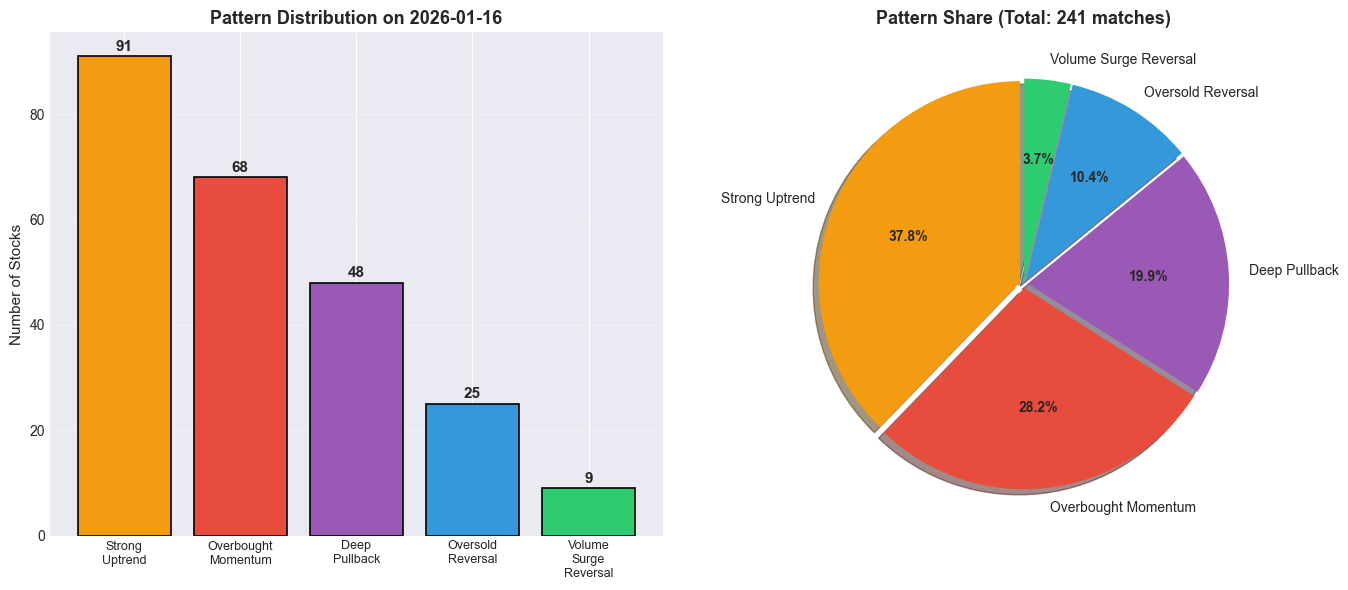

In [6]:
# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Color mapping for patterns
colors = {
    'Volume_Surge_Reversal': '#2ecc71',  # Green
    'Oversold_Reversal': '#3498db',       # Blue
    'Deep_Pullback': '#9b59b6',           # Purple
    'Overbought_Momentum': '#e74c3c',     # Red
    'Strong_Uptrend': '#f39c12'           # Orange
}

# Sort by count for better visualization
sorted_patterns = sorted(pattern_counts.items(), key=lambda x: x[1], reverse=True)
pattern_names = [p[0] for p in sorted_patterns]
counts = [p[1] for p in sorted_patterns]
bar_colors = [colors[p] for p in pattern_names]

# 1. Bar chart
bars = axes[0].bar(range(len(pattern_names)), counts, color=bar_colors, edgecolor='black', linewidth=1.2)
axes[0].set_xticks(range(len(pattern_names)))
axes[0].set_xticklabels([p.replace('_', '\n') for p in pattern_names], fontsize=9)
axes[0].set_ylabel('Number of Stocks', fontsize=11)
axes[0].set_title(f'Pattern Distribution on {SCAN_DATE}', fontsize=13, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Add count labels on bars
for bar, count in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                 str(count), ha='center', va='bottom', fontsize=11, fontweight='bold')

# 2. Pie chart
if sum(counts) > 0:
    # Only show patterns with matches in pie chart
    pie_data = [(p, c) for p, c in sorted_patterns if c > 0]
    if pie_data:
        pie_names = [p[0].replace('_', ' ') for p in pie_data]
        pie_counts = [p[1] for p in pie_data]
        pie_colors = [colors[p[0]] for p in pie_data]
        
        wedges, texts, autotexts = axes[1].pie(
            pie_counts, 
            labels=pie_names, 
            colors=pie_colors,
            autopct='%1.1f%%',
            startangle=90,
            explode=[0.02] * len(pie_counts),
            shadow=True
        )
        axes[1].set_title(f'Pattern Share (Total: {sum(pie_counts)} matches)', fontsize=13, fontweight='bold')
        
        # Make percentage text more readable
        for autotext in autotexts:
            autotext.set_fontsize(10)
            autotext.set_fontweight('bold')
    else:
        axes[1].text(0.5, 0.5, 'No patterns detected', ha='center', va='center', fontsize=14)
        axes[1].set_title('Pattern Share', fontsize=13, fontweight='bold')
else:
    axes[1].text(0.5, 0.5, 'No patterns detected', ha='center', va='center', fontsize=14)
    axes[1].set_title('Pattern Share', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

## 7. Detailed Pattern Results

In [7]:
# Show stocks matching each pattern
print("=" * 60)
print("STOCKS MATCHING EACH PATTERN")
print("=" * 60)

for pattern in pattern_names:
    tickers = pattern_details[pattern]
    print(f"\n{pattern} ({len(tickers)} stocks):")
    print("-" * 40)
    if tickers:
        # Display in rows of 10
        for i in range(0, len(tickers), 10):
            print("  " + ", ".join(tickers[i:i+10]))
    else:
        print("  (No matches)")

STOCKS MATCHING EACH PATTERN

Strong_Uptrend (91 stocks):
----------------------------------------
  AEE, AEP, AKAM, AMD, AMP, AMT, AOS, ARE, AVB, BEN
  BLK, BRO, BX, CASY, CBOE, CBRE, CCI, CF, CFG, CHD
  CNP, COST, CPT, D, DOC, DRI, DTE, DUK, ED, ESS
  ETR, EVRG, EXC, EXR, FAST, FE, FITB, GLW, GPC, GWW
  HII, HON, HSIC, HWM, ICE, IEX, IFF, INVH, IR, ITW
  KIM, LH, LMT, LNT, LOW, MO, MPWR, MSCI, NDAQ, NDSN
  NEE, NI, NOC, O, PLD, PM, PNR, PNW, POOL, PPG
  PPL, PSA, Q, ROL, RTX, SCHW, SO, SPGI, SRE, STE
  SWK, SYK, TDG, TDY, TGT, TPL, UDR, VICI, WEC, WM
  WY

Overbought_Momentum (68 stocks):
----------------------------------------
  ALGN, AMAT, AOS, APD, APH, ARE, BALL, BEN, CASY, CBOE
  CF, CHRW, CL, CMI, COST, CVX, DOC, DRI, DTE, EME
  EMR, EVRG, EXR, FE, FIX, GPC, HD, HII, HON, IEX
  IR, IRM, IVZ, KLAC, LHX, LMT, LOW, LRCX, LYB, MCHP
  MO, MRNA, MSI, MU, NDSN, NI, NOC, O, PM, PNW
  POOL, PPG, PPL, PSA, Q, RTX, SHW, SLB, SNDK, SWK
  TDG, TDY, TER, TGT, TPL, WMT, WSM, WY

Deep_Pullbac

In [8]:
# Create summary DataFrame
summary_data = []
for pattern in pattern_names:
    count = pattern_counts[pattern]
    pct = count / len(stock_data) * 100 if len(stock_data) > 0 else 0
    summary_data.append({
        'Pattern': pattern,
        'Count': count,
        'Percentage': f"{pct:.1f}%",
        'Sample Tickers': ', '.join(pattern_details[pattern][:5]) + ('...' if len(pattern_details[pattern]) > 5 else '')
    })

summary_df = pd.DataFrame(summary_data)
print("\nSummary Table:")
display(summary_df)


Summary Table:


,Pattern,Count,Percentage,Sample Tickers
0,Strong_Uptrend,91,17.8%,"AEE, AEP, AKAM, AMD, AMP..."
1,Overbought_Momentum,68,13.3%,"ALGN, AMAT, AOS, APD, APH..."
2,Deep_Pullback,48,9.4%,"ADBE, ADSK, AIG, ALL, APP..."
3,Oversold_Reversal,25,4.9%,"AAPL, ADBE, ALL, APP, BR..."
4,Volume_Surge_Reversal,9,1.8%,"ACGL, ADBE, ADSK, APP, BKNG..."
